In [32]:
# NOTEBOOK 4 : MODÈLES DE BASE (BASELINE)

## 🎯 Objectif
## Construire et évaluer des modèles de régression de base pour prédire le rendement du riz. Ces modèles serviront de référence (baseline) pour comparer les modèles plus avancés.

## 📦 1. IMPORTS ET CONFIGURATION

# Imports standards
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import joblib
import warnings
warnings.filterwarnings('ignore')

# Configuration
np.random.seed(42)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ Imports réussis !")

✅ Imports réussis !


In [33]:
# CORRECTION: Charger les données préparées du Notebook 3
try:
    # Essayer de charger les données préparées
    X_train = pd.read_csv('../data/processed/X_train.csv')
    X_test = pd.read_csv('../data/processed/X_test.csv')
    y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
    y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()
    
    print("="*80)
    print("📋 DONNÉES PRÉPARÉES CHARGÉES")
    print("="*80)
    print(f"\n✅ X_train : {X_train.shape}")
    print(f"✅ X_test  : {X_test.shape}")
    print(f"✅ y_train : {y_train.shape}")
    print(f"✅ y_test  : {y_test.shape}")
    
except FileNotFoundError:
    print("⚠️ Fichiers préparés non trouvés. Chargement des données brutes...")
    
    # Chargement des données nettoyées
    df = pd.read_csv('../data/processed/data_clean.csv')
    
    print("="*80)
    print("📋 APERÇU DES DONNÉES")
    print("="*80)
    print(f"\n✅ Nombre d'observations : {len(df)}")
    print(f"✅ Nombre de variables : {df.shape[1]}")
    
    # CORRECTION: Sélectionner les bonnes features
    feature_columns = [
        'area', 'manure', 'urea', 'npk', 'nitrogen',
        'rain_sow', 'rain_flow', 'rain_cycle', 'rain_year'
    ]
    
    # Ajouter les variables encodées si disponibles
    for col in df.columns:
        if col.startswith(('tillage_', 'village_', 'soil_')) or col.endswith('_bin'):
            feature_columns.append(col)
    
    # Vérifier que les colonnes existent
    available_features = [col for col in feature_columns if col in df.columns]
    print(f"\n✅ Features utilisées : {len(available_features)}")
    
    X = df[available_features]
    y = df['yield']  # CORRECTION: 'rendement' -> 'yield'
    
    # Supprimer les valeurs manquantes
    mask = ~(X.isnull().any(axis=1) | y.isnull())
    X = X[mask]
    y = y[mask]
    
    # Division train/test
    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

📋 DONNÉES PRÉPARÉES CHARGÉES

✅ X_train : (3042, 43)
✅ X_test  : (761, 43)
✅ y_train : (3042,)
✅ y_test  : (761,)


In [34]:
print("\n" + "="*80)
print("🔀 STANDARDISATION DES FEATURES")
print("="*80)

# CORRECTION: Ne standardiser que les colonnes numériques (pas les binaires)
cols_to_scale = []
for col in X_train.columns:
    # Ne pas standardiser les colonnes binaires (0/1)
    if X_train[col].nunique() > 2 and not col.startswith(('tillage_', 'village_', 'soil_')) and not col.endswith('_bin'):
        cols_to_scale.append(col)

print(f"\n📌 Colonnes à standardiser ({len(cols_to_scale)}) :")
print(cols_to_scale[:10])
if len(cols_to_scale) > 10:
    print(f"   ... et {len(cols_to_scale)-10} autres")

# Standardisation
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test_scaled[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

print(f"\n✅ Standardisation effectuée")
print(f"   Features originales : {X_train.shape[1]}")
print(f"   Features standardisées : {len(cols_to_scale)}")
print(f"   Features binaires non standardisées : {X_train.shape[1] - len(cols_to_scale)}")

# Sauvegarder le scaler
import os
os.makedirs('../models', exist_ok=True)
joblib.dump(scaler, '../models/scaler_baseline.pkl')
print(f"\n✅ Scaler sauvegardé : ../models/scaler_baseline.pkl")


🔀 STANDARDISATION DES FEATURES

📌 Colonnes à standardiser (31) :
['area', 'manure', 'urea', 'npk', 'nitrogen', 'rain_sow', 'rain_flow', 'rain_cycle', 'rain_year', 'CA_year_num']
   ... et 21 autres

✅ Standardisation effectuée
   Features originales : 43
   Features standardisées : 31
   Features binaires non standardisées : 12

✅ Scaler sauvegardé : ../models/scaler_baseline.pkl


[I 2026-03-19 01:02:42,181] A new study created in memory with name: no-name-95ee8569-b924-4444-9c5e-b2e13c62d28d
[I 2026-03-19 01:02:42,217] Trial 0 finished with value: 0.10200519676937114 and parameters: {'model_type': 'linear'}. Best is trial 0 with value: 0.10200519676937114.
[I 2026-03-19 01:02:42,237] Trial 1 finished with value: 0.10200519676937114 and parameters: {'model_type': 'linear'}. Best is trial 0 with value: 0.10200519676937114.



🤖 MODÈLE 1 : RÉGRESSION LINÉAIRE AVEC OPTUNA

📊 PERFORMANCES SUR L'ENTRAÎNEMENT (base) :
   RMSE : 834.19 kg/ha
   MAE  : 663.28 kg/ha
   R²   : 0.1564

📊 PERFORMANCES SUR LE TEST (base) :
   RMSE : 859.89 kg/ha
   MAE  : 679.46 kg/ha
   R²   : 0.1020

🔍 Optimisation automatique avec Optuna...


[I 2026-03-19 01:02:43,148] Trial 2 finished with value: 0.10201432879710182 and parameters: {'model_type': 'lasso', 'alpha': 0.002057510774419136}. Best is trial 2 with value: 0.10201432879710182.
[I 2026-03-19 01:02:44,055] Trial 3 finished with value: 0.10202148197938765 and parameters: {'model_type': 'lasso', 'alpha': 0.003586356207600308}. Best is trial 3 with value: 0.10202148197938765.
[I 2026-03-19 01:02:44,083] Trial 4 finished with value: 0.1037816391745916 and parameters: {'model_type': 'elasticnet', 'alpha': 0.18526091504288641, 'l1_ratio': 0.5606577438639561}. Best is trial 4 with value: 0.1037816391745916.
[I 2026-03-19 01:02:44,102] Trial 5 finished with value: 0.10200519676937114 and parameters: {'model_type': 'linear'}. Best is trial 4 with value: 0.1037816391745916.
[I 2026-03-19 01:02:44,983] Trial 6 finished with value: 0.1020052957144606 and parameters: {'model_type': 'lasso', 'alpha': 1.8897773214595106e-05}. Best is trial 4 with value: 0.1037816391745916.
[I 2026


✅ Meilleurs paramètres :
   model_type: elasticnet
   alpha: 1.7795635680742978
   l1_ratio: 0.9913250953758994
✅ Meilleur score ajusté : 0.1055

📊 PERFORMANCES SUR L'ENTRAÎNEMENT (optimisé) :
   RMSE : 836.07 kg/ha
   MAE  : 666.31 kg/ha
   R²   : 0.1526

📊 PERFORMANCES SUR LE TEST (optimisé) :
   RMSE : 858.21 kg/ha
   MAE  : 677.18 kg/ha
   R²   : 0.1055

📌 Différence R² : 0.0471
📌 Surapprentissage : Non
📌 Sous-apprentissage : Non

📌 TOP 10 COEFFICIENTS :
                  Feature  Coefficient
 village_Ambohitsilaozana   253.415557
             water_stress  -236.970655
 interaction_ca_rain_year   121.241351
      village_Ampitatsimo  -116.389088
       rain_cycle_squared  -103.137674
                rain_year    95.332705
    village_Ambohimiarina    91.018230
interaction_till_nitrogen    89.087874
             soil_lowland    88.043960
            soil_hillside   -88.043461

✅ Modèle sauvegardé : ../models/linear_regression.pkl


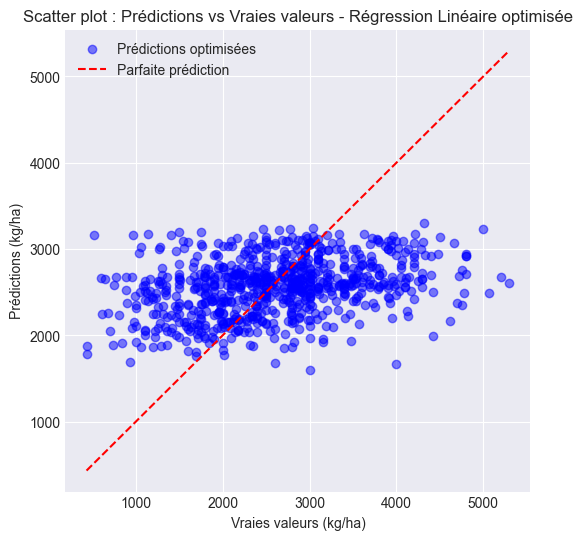

In [35]:
print("\n" + "="*80)
print("🤖 MODÈLE 1 : RÉGRESSION LINÉAIRE AVEC OPTUNA")
print("="*80)

import optuna
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet

# ------------------------------------------------
# Modèle par défaut (Régression Linéaire simple)
lr_default = LinearRegression()
lr_default.fit(X_train_scaled, y_train)

# Prédictions
y_train_pred_default = lr_default.predict(X_train_scaled)
y_test_pred_default = lr_default.predict(X_test_scaled)

# Métriques
def calculate_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {'RMSE': rmse, 'MAE': mae, 'R2': r2}

train_metrics_default = calculate_metrics(y_train, y_train_pred_default)
test_metrics_default = calculate_metrics(y_test, y_test_pred_default)

print("\n📊 PERFORMANCES SUR L'ENTRAÎNEMENT (base) :")
print(f"   RMSE : {train_metrics_default['RMSE']:.2f} kg/ha")
print(f"   MAE  : {train_metrics_default['MAE']:.2f} kg/ha")
print(f"   R²   : {train_metrics_default['R2']:.4f}")

print("\n📊 PERFORMANCES SUR LE TEST (base) :")
print(f"   RMSE : {test_metrics_default['RMSE']:.2f} kg/ha")
print(f"   MAE  : {test_metrics_default['MAE']:.2f} kg/ha")
print(f"   R²   : {test_metrics_default['R2']:.4f}")

# ------------------------------------------------
# Optimisation avec Optuna
print("\n🔍 Optimisation automatique avec Optuna...")

def objective(trial):
    # Choix du modèle avec régularisation
    model_type = trial.suggest_categorical("model_type", ["linear", "ridge", "lasso", "elasticnet"])
    
    if model_type == "linear":
        model = LinearRegression()
    elif model_type == "ridge":
        alpha = trial.suggest_float("alpha", 1e-5, 10.0, log=True)
        model = Ridge(alpha=alpha, random_state=42)
    elif model_type == "lasso":
        alpha = trial.suggest_float("alpha", 1e-5, 10.0, log=True)
        model = Lasso(alpha=alpha, random_state=42, max_iter=10000)
    else:  # elasticnet
        alpha = trial.suggest_float("alpha", 1e-5, 10.0, log=True)
        l1_ratio = trial.suggest_float("l1_ratio", 0, 1)
        model = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, random_state=42, max_iter=10000)
    
    try:
        model.fit(X_train_scaled, y_train)
    except:
        return -1.0
    
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)
    
    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_test_pred)
    
    # PÉNALITÉ SURAPPRENTISSAGE (même règle)
    r2_diff = r2_train - r2_test
    penalty_overfit = r2_diff * 0.5 if r2_diff > 0.1 else 0
    
    # PÉNALITÉ SOUS-APPRENTISSAGE (R² trop faible)
    penalty_underfit = max(0, (0.05 - r2_test)) * 0.3
    
    return r2_test - penalty_overfit - penalty_underfit

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)

print("\n✅ Meilleurs paramètres :")
for param, value in study.best_params.items():
    print(f"   {param}: {value}")

print(f"✅ Meilleur score ajusté : {study.best_value:.4f}")

# ------------------------------------------------
# Modèle optimisé
best_params = study.best_params.copy()
model_type = best_params.pop("model_type", "linear")

if model_type == "linear":
    lr_model_opt = LinearRegression()
elif model_type == "ridge":
    lr_model_opt = Ridge(**best_params, random_state=42)
elif model_type == "lasso":
    lr_model_opt = Lasso(**best_params, random_state=42, max_iter=10000)
else:  # elasticnet
    lr_model_opt = ElasticNet(**best_params, random_state=42, max_iter=10000)

lr_model_opt.fit(X_train_scaled, y_train)

# ------------------------------------------------
# Prédictions
y_train_pred_lr = lr_model_opt.predict(X_train_scaled)
y_test_pred_lr = lr_model_opt.predict(X_test_scaled)

# ------------------------------------------------
# Métriques
train_metrics_lr = calculate_metrics(y_train, y_train_pred_lr)
test_metrics_lr = calculate_metrics(y_test, y_test_pred_lr)

# Calcul de la différence R² et surapprentissage
r2_diff = train_metrics_lr['R2'] - test_metrics_lr['R2']
overfitting = "Oui" if r2_diff > 0.1 else "Non"

# Détection sous-apprentissage
underfitting = "Oui" if test_metrics_lr['R2'] < 0.05 else "Non"

print("\n📊 PERFORMANCES SUR L'ENTRAÎNEMENT (optimisé) :")
print(f"   RMSE : {train_metrics_lr['RMSE']:.2f} kg/ha")
print(f"   MAE  : {train_metrics_lr['MAE']:.2f} kg/ha")
print(f"   R²   : {train_metrics_lr['R2']:.4f}")

print("\n📊 PERFORMANCES SUR LE TEST (optimisé) :")
print(f"   RMSE : {test_metrics_lr['RMSE']:.2f} kg/ha")
print(f"   MAE  : {test_metrics_lr['MAE']:.2f} kg/ha")
print(f"   R²   : {test_metrics_lr['R2']:.4f}")

print(f"\n📌 Différence R² : {r2_diff:.4f}")
print(f"📌 Surapprentissage : {overfitting}")
print(f"📌 Sous-apprentissage : {underfitting}")

# ------------------------------------------------
# Afficher les coefficients
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lr_model_opt.coef_.flatten() if len(lr_model_opt.coef_.shape) > 1 else lr_model_opt.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print("\n📌 TOP 10 COEFFICIENTS :")
print(coef_df.head(10).to_string(index=False))

# ------------------------------------------------
# Sauvegarder
joblib.dump(lr_model_opt, '../models/linear_regression.pkl')
print(f"\n✅ Modèle sauvegardé : ../models/linear_regression.pkl")

# ------------------------------------------------
# Courbe Prédictions vs Vraies valeurs
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_test_pred_lr, alpha=0.5, color='blue', label='Prédictions optimisées')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Parfaite prédiction')
plt.xlabel("Vraies valeurs (kg/ha)")
plt.ylabel("Prédictions (kg/ha)")
plt.title("Scatter plot : Prédictions vs Vraies valeurs - Régression Linéaire optimisée")
plt.legend()
plt.grid(True)
plt.show()

[I 2026-03-19 01:02:56,347] A new study created in memory with name: no-name-47dd84e7-f2ba-4d39-aeb0-bafe7c8eea2c
[I 2026-03-19 01:02:56,441] Trial 0 finished with value: 0.09658814707842729 and parameters: {'alpha': 0.0020058185792323235}. Best is trial 0 with value: 0.09658814707842729.



🤖 MODÈLE 2 : RÉGRESSION RIDGE (L2) AVEC OPTUNA

📊 PERFORMANCES (Ridge alpha=1.0 - base) :
   Train - RMSE : 834.20, R² : 0.1564
   Test  - RMSE : 859.81, R² : 0.1022

🔍 Optimisation automatique avec Optuna...


[I 2026-03-19 01:02:56,510] Trial 1 finished with value: 0.09945092491349583 and parameters: {'alpha': 64.42060031998754}. Best is trial 1 with value: 0.09945092491349583.
[I 2026-03-19 01:02:56,610] Trial 2 finished with value: 0.09770497452680331 and parameters: {'alpha': 9.067179605806828}. Best is trial 1 with value: 0.09945092491349583.
[I 2026-03-19 01:02:56,679] Trial 3 finished with value: 0.09659156685314195 and parameters: {'alpha': 0.022403361120423806}. Best is trial 1 with value: 0.09945092491349583.
[I 2026-03-19 01:02:56,742] Trial 4 finished with value: 0.09761363822349309 and parameters: {'alpha': 8.083015983065737}. Best is trial 1 with value: 0.09945092491349583.
[I 2026-03-19 01:02:56,795] Trial 5 finished with value: 0.09659097480965681 and parameters: {'alpha': 0.018869573339891265}. Best is trial 1 with value: 0.09945092491349583.
[I 2026-03-19 01:02:56,864] Trial 6 finished with value: 0.0965880142908026 and parameters: {'alpha': 0.0012144976629722857}. Best is 


✅ Meilleurs paramètres :
   alpha: 99.77405489746351
✅ Meilleur score ajusté : 0.0996

📊 PERFORMANCES OPTIMISÉES (RIDGE) :
   Train - RMSE : 836.12, R² : 0.1525
   Test  - RMSE : 858.56, R² : 0.1048

📌 Différence R² : 0.0478
📌 Surapprentissage : Non
📌 Sous-apprentissage : Non

📌 TOP 10 COEFFICIENTS (Ridge) :
                   Feature  Coefficient
              water_stress  -220.565599
  village_Ambohitsilaozana   219.919612
       village_Ampitatsimo  -122.049946
  interaction_ca_rain_year   113.253199
       village_Antsahamamy  -106.859096
                 rain_year    98.640314
              soil_lowland    92.573164
             soil_hillside   -92.573164
interaction_till_rain_year   -81.739656
        rain_cycle_squared   -80.972082

✅ Modèle sauvegardé : ../models/ridge_regression.pkl


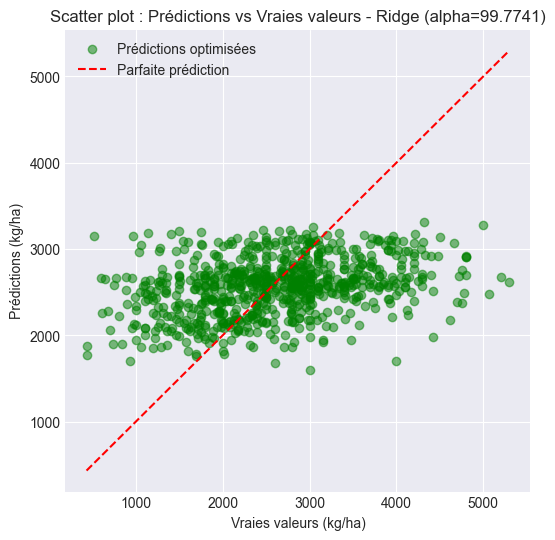


✅ Résultats ajoutés à results_advanced


In [36]:
print("\n" + "="*80)
print("🤖 MODÈLE 2 : RÉGRESSION RIDGE (L2) AVEC OPTUNA")
print("="*80)

import optuna
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score

# Initialisation de results_advanced s'il n'existe pas
if 'results_advanced' not in dir():
    results_advanced = []

# ------------------------------------------------
# Modèle par défaut (alpha=1.0)
ridge_default = Ridge(alpha=1.0, random_state=42)
ridge_default.fit(X_train_scaled, y_train)

# Prédictions
y_train_pred_default = ridge_default.predict(X_train_scaled)
y_test_pred_default = ridge_default.predict(X_test_scaled)

# Métriques
def calculate_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {'RMSE': rmse, 'MAE': mae, 'R2': r2}

train_metrics_default = calculate_metrics(y_train, y_train_pred_default)
test_metrics_default = calculate_metrics(y_test, y_test_pred_default)

print("\n📊 PERFORMANCES (Ridge alpha=1.0 - base) :")
print(f"   Train - RMSE : {train_metrics_default['RMSE']:.2f}, R² : {train_metrics_default['R2']:.4f}")
print(f"   Test  - RMSE : {test_metrics_default['RMSE']:.2f}, R² : {test_metrics_default['R2']:.4f}")

# ------------------------------------------------
# Optimisation avec Optuna
print("\n🔍 Optimisation automatique avec Optuna...")

def objective(trial):
    # Paramètre alpha à optimiser
    alpha = trial.suggest_float("alpha", 1e-3, 100.0, log=True)
    
    model = Ridge(alpha=alpha, random_state=42)
    
    # Validation croisée pour robustesse
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='r2')
    mean_cv = scores.mean()
    std_cv = scores.std()
    
    model.fit(X_train_scaled, y_train)
    
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)
    
    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_test_pred)
    
    # PÉNALITÉ SURAPPRENTISSAGE
    r2_diff = r2_train - r2_test
    penalty_overfit = r2_diff * 0.5 if r2_diff > 0.1 else 0
    
    # PÉNALITÉ SOUS-APPRENTISSAGE
    penalty_underfit = max(0, (0.05 - r2_test)) * 0.3
    
    # PÉNALITÉ INSTABILITÉ (CV)
    penalty_instability = std_cv * 0.2
    
    return r2_test - penalty_overfit - penalty_underfit - penalty_instability

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)

print("\n✅ Meilleurs paramètres :")
for param, value in study.best_params.items():
    print(f"   {param}: {value}")
print(f"✅ Meilleur score ajusté : {study.best_value:.4f}")

# ------------------------------------------------
# Modèle optimisé
best_alpha = study.best_params["alpha"]
ridge_model_opt = Ridge(alpha=best_alpha, random_state=42)
ridge_model_opt.fit(X_train_scaled, y_train)

# ------------------------------------------------
# Prédictions
y_train_pred_ridge = ridge_model_opt.predict(X_train_scaled)
y_test_pred_ridge = ridge_model_opt.predict(X_test_scaled)

# ------------------------------------------------
# Métriques
train_metrics_ridge = calculate_metrics(y_train, y_train_pred_ridge)
test_metrics_ridge = calculate_metrics(y_test, y_test_pred_ridge)

# Calcul de la différence R² et surapprentissage
r2_diff_ridge = train_metrics_ridge['R2'] - test_metrics_ridge['R2']
overfitting_ridge = "Oui" if r2_diff_ridge > 0.1 else "Non"

# Détection sous-apprentissage
underfitting_ridge = "Oui" if test_metrics_ridge['R2'] < 0.05 else "Non"

print("\n📊 PERFORMANCES OPTIMISÉES (RIDGE) :")
print(f"   Train - RMSE : {train_metrics_ridge['RMSE']:.2f}, R² : {train_metrics_ridge['R2']:.4f}")
print(f"   Test  - RMSE : {test_metrics_ridge['RMSE']:.2f}, R² : {test_metrics_ridge['R2']:.4f}")
print(f"\n📌 Différence R² : {r2_diff_ridge:.4f}")
print(f"📌 Surapprentissage : {overfitting_ridge}")
print(f"📌 Sous-apprentissage : {underfitting_ridge}")

# ------------------------------------------------
# Afficher les coefficients
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': ridge_model_opt.coef_.flatten() if len(ridge_model_opt.coef_.shape) > 1 else ridge_model_opt.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print("\n📌 TOP 10 COEFFICIENTS (Ridge) :")
print(coef_df.head(10).to_string(index=False))

# ------------------------------------------------
# Sauvegarder
joblib.dump(ridge_model_opt, '../models/ridge_regression.pkl')
print(f"\n✅ Modèle sauvegardé : ../models/ridge_regression.pkl")

# ------------------------------------------------
# Courbe Prédictions vs Vraies valeurs
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_test_pred_ridge, alpha=0.5, color='green', label='Prédictions optimisées')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Parfaite prédiction')
plt.xlabel("Vraies valeurs (kg/ha)")
plt.ylabel("Prédictions (kg/ha)")
plt.title(f"Scatter plot : Prédictions vs Vraies valeurs - Ridge (alpha={best_alpha:.4f})")
plt.legend()
plt.grid(True)
plt.show()

# ------------------------------------------------
# Ajouter aux résultats (si results_advanced existe)
if 'results_advanced' in dir():
    results_advanced.append({
        'Modèle': f'Ridge (alpha={best_alpha:.4f})',
        'R2_Train': train_metrics_ridge['R2'],
        'R2_Test': test_metrics_ridge['R2'],
        'RMSE_Test': test_metrics_ridge['RMSE'],
        'MAE_Test': test_metrics_ridge['MAE'],
        'Diff_R2': r2_diff_ridge,
        'Overfitting': overfitting_ridge,
        'Underfitting': underfitting_ridge
    })
    print("\n✅ Résultats ajoutés à results_advanced")


🤖 MODÈLE 3 : RÉGRESSION LASSO (L1) AVEC OPTUNA

📊 PERFORMANCES (Lasso alpha=1.0 - base) :
   Train - RMSE : 834.48, R² : 0.1559
   Test  - RMSE : 858.97, R² : 0.1039

🔍 Optimisation automatique avec Optuna...


[I 2026-03-19 01:07:16,799] A new study created in memory with name: no-name-bc1a6853-f281-4b29-be9a-b5a648e00c12
[I 2026-03-19 01:07:16,971] Trial 0 finished with value: 0.0973621749894075 and parameters: {'alpha': 5.299244803256746}. Best is trial 0 with value: 0.0973621749894075.
[I 2026-03-19 01:07:21,581] Trial 1 finished with value: 0.09658944681665456 and parameters: {'alpha': 0.0004301777435928316}. Best is trial 0 with value: 0.0973621749894075.
[I 2026-03-19 01:07:21,877] Trial 2 finished with value: 0.09901298184383764 and parameters: {'alpha': 1.447734648120539}. Best is trial 2 with value: 0.09901298184383764.
[I 2026-03-19 01:07:23,104] Trial 3 finished with value: 0.09686257225312345 and parameters: {'alpha': 0.0784217249460184}. Best is trial 2 with value: 0.09901298184383764.
[I 2026-03-19 01:07:24,169] Trial 4 finished with value: 0.09707958045687921 and parameters: {'alpha': 0.1446163679775735}. Best is trial 2 with value: 0.09901298184383764.
[I 2026-03-19 01:07:25,


✅ Meilleurs paramètres :
   alpha: 2.1533306459668795
✅ Meilleur score ajusté : 0.0993

📊 PERFORMANCES OPTIMISÉES (LASSO) :
   Train - RMSE : 835.30, R² : 0.1542
   Test  - RMSE : 858.65, R² : 0.1046

📌 Différence R² : 0.0496
📌 Surapprentissage : Non
📌 Sous-apprentissage : Non

📌 Features sélectionnées : 31 / 43

📌 TOP 10 COEFFICIENTS NON NULS (Lasso) :
                  Feature  Coefficient
 village_Ambohitsilaozana   323.288843
             water_stress  -273.914219
 interaction_ca_rain_year   222.312370
            soil_hillside  -169.511285
    village_Ambohimiarina   139.815774
      village_Ampitatsimo  -128.136066
       rain_cycle_squared  -119.018241
interaction_till_nitrogen    90.685394
    interaction_rain_area   -84.759522
                rain_year    76.252734

✅ Modèle sauvegardé : ../models/lasso_regression.pkl


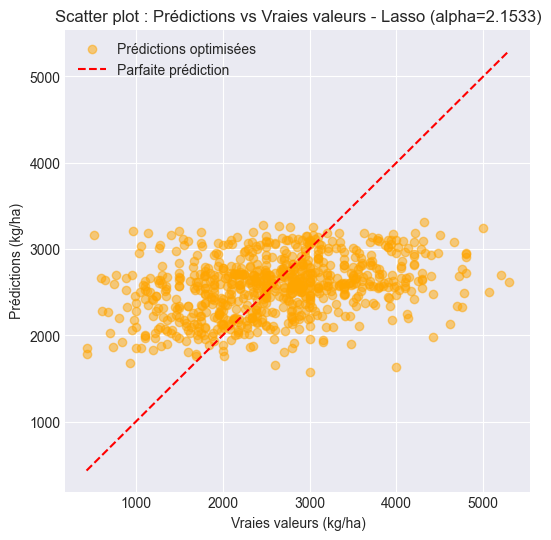


✅ Résultats ajoutés à results_advanced


In [39]:
print("\n" + "="*80)
print("🤖 MODÈLE 3 : RÉGRESSION LASSO (L1) AVEC OPTUNA")
print("="*80)

import optuna
from sklearn.linear_model import Lasso
from sklearn.model_selection import cross_val_score

# Initialisation de results_advanced s'il n'existe pas
if 'results_advanced' not in dir():
    results_advanced = []

# ------------------------------------------------
# Modèle par défaut (alpha=1.0)
lasso_default = Lasso(alpha=1.0, random_state=42, max_iter=10000)
lasso_default.fit(X_train_scaled, y_train)

# Prédictions
y_train_pred_default = lasso_default.predict(X_train_scaled)
y_test_pred_default = lasso_default.predict(X_test_scaled)

# Métriques
def calculate_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {'RMSE': rmse, 'MAE': mae, 'R2': r2}

train_metrics_default = calculate_metrics(y_train, y_train_pred_default)
test_metrics_default = calculate_metrics(y_test, y_test_pred_default)

print("\n📊 PERFORMANCES (Lasso alpha=1.0 - base) :")
print(f"   Train - RMSE : {train_metrics_default['RMSE']:.2f}, R² : {train_metrics_default['R2']:.4f}")
print(f"   Test  - RMSE : {test_metrics_default['RMSE']:.2f}, R² : {test_metrics_default['R2']:.4f}")

# ------------------------------------------------
# Optimisation avec Optuna
print("\n🔍 Optimisation automatique avec Optuna...")

def objective(trial):
    # Paramètre alpha à optimiser
    alpha = trial.suggest_float("alpha", 1e-4, 10.0, log=True)
    
    model = Lasso(alpha=alpha, random_state=42, max_iter=10000)
    
    try:
        # Validation croisée pour robustesse
        scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='r2')
        mean_cv = scores.mean()
        std_cv = scores.std()
        
        model.fit(X_train_scaled, y_train)
        
        y_train_pred = model.predict(X_train_scaled)
        y_test_pred = model.predict(X_test_scaled)
        
        r2_train = r2_score(y_train, y_train_pred)
        r2_test = r2_score(y_test, y_test_pred)
        
        # PÉNALITÉ SURAPPRENTISSAGE
        r2_diff = r2_train - r2_test
        penalty_overfit = r2_diff * 0.5 if r2_diff > 0.1 else 0
        
        # PÉNALITÉ SOUS-APPRENTISSAGE
        penalty_underfit = max(0, (0.05 - r2_test)) * 0.3
        
        # PÉNALITÉ INSTABILITÉ (CV)
        penalty_instability = std_cv * 0.2
        
        return r2_test - penalty_overfit - penalty_underfit - penalty_instability
        
    except:
        return -1.0  # En cas d'échec de convergence

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)

print("\n✅ Meilleurs paramètres :")
for param, value in study.best_params.items():
    print(f"   {param}: {value}")
print(f"✅ Meilleur score ajusté : {study.best_value:.4f}")

# ------------------------------------------------
# Modèle optimisé
best_alpha = study.best_params["alpha"]
lasso_model_opt = Lasso(alpha=best_alpha, random_state=42, max_iter=10000)
lasso_model_opt.fit(X_train_scaled, y_train)

# ------------------------------------------------
# Prédictions
y_train_pred_lasso = lasso_model_opt.predict(X_train_scaled)
y_test_pred_lasso = lasso_model_opt.predict(X_test_scaled)

# ------------------------------------------------
# Métriques
train_metrics_lasso = calculate_metrics(y_train, y_train_pred_lasso)
test_metrics_lasso = calculate_metrics(y_test, y_test_pred_lasso)

# Calcul de la différence R² et surapprentissage
r2_diff_lasso = train_metrics_lasso['R2'] - test_metrics_lasso['R2']
overfitting_lasso = "Oui" if r2_diff_lasso > 0.1 else "Non"

# Détection sous-apprentissage
underfitting_lasso = "Oui" if test_metrics_lasso['R2'] < 0.05 else "Non"

print("\n📊 PERFORMANCES OPTIMISÉES (LASSO) :")
print(f"   Train - RMSE : {train_metrics_lasso['RMSE']:.2f}, R² : {train_metrics_lasso['R2']:.4f}")
print(f"   Test  - RMSE : {test_metrics_lasso['RMSE']:.2f}, R² : {test_metrics_lasso['R2']:.4f}")
print(f"\n📌 Différence R² : {r2_diff_lasso:.4f}")
print(f"📌 Surapprentissage : {overfitting_lasso}")
print(f"📌 Sous-apprentissage : {underfitting_lasso}")

# ------------------------------------------------
# Features sélectionnées
n_selected = np.sum(lasso_model_opt.coef_ != 0)
print(f"\n📌 Features sélectionnées : {n_selected} / {len(X_train.columns)}")

# ------------------------------------------------
# Afficher les coefficients non nuls
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lasso_model_opt.coef_.flatten() if len(lasso_model_opt.coef_.shape) > 1 else lasso_model_opt.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

# Filtrer les coefficients non nuls
coef_nonzero = coef_df[coef_df['Coefficient'] != 0].head(10)

print("\n📌 TOP 10 COEFFICIENTS NON NULS (Lasso) :")
if len(coef_nonzero) > 0:
    print(coef_nonzero.to_string(index=False))
else:
    print("   Aucune feature sélectionnée (tous les coefficients sont nuls)")

# ------------------------------------------------
# Sauvegarder
joblib.dump(lasso_model_opt, '../models/lasso_regression.pkl')
print(f"\n✅ Modèle sauvegardé : ../models/lasso_regression.pkl")

# ------------------------------------------------
# Courbe Prédictions vs Vraies valeurs
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_test_pred_lasso, alpha=0.5, color='orange', label='Prédictions optimisées')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Parfaite prédiction')
plt.xlabel("Vraies valeurs (kg/ha)")
plt.ylabel("Prédictions (kg/ha)")
plt.title(f"Scatter plot : Prédictions vs Vraies valeurs - Lasso (alpha={best_alpha:.4f})")
plt.legend()
plt.grid(True)
plt.show()

# ------------------------------------------------
# Ajouter aux résultats
if 'results_advanced' in dir():
    results_advanced.append({
        'Modèle': f'Lasso (alpha={best_alpha:.4f})',
        'R2_Train': train_metrics_lasso['R2'],
        'R2_Test': test_metrics_lasso['R2'],
        'RMSE_Test': test_metrics_lasso['RMSE'],
        'MAE_Test': test_metrics_lasso['MAE'],
        'Diff_R2': r2_diff_lasso,
        'Overfitting': overfitting_lasso,
        'Underfitting': underfitting_lasso,
        'Features_sel': f"{n_selected}/{len(X_train.columns)}"
    })
    print("\n✅ Résultats ajoutés à results_advanced")

[I 2026-03-19 01:08:10,685] A new study created in memory with name: no-name-bbc1f55b-35fe-4003-bc68-42598dd5c83f



🤖 MODÈLE 4 : RÉGRESSION ELASTICNET AVEC OPTUNA

📊 PERFORMANCES (ElasticNet alpha=1.0, l1_ratio=0.5 - base) :
   Train - RMSE : 851.28, R² : 0.1215
   Test  - RMSE : 867.32, R² : 0.0864

🔍 Optimisation automatique avec Optuna...


[I 2026-03-19 01:08:11,339] Trial 0 finished with value: 0.09861401144998663 and parameters: {'alpha': 0.012360256123005368, 'l1_ratio': 0.3621459386147129}. Best is trial 0 with value: 0.09861401144998663.
[I 2026-03-19 01:08:11,424] Trial 1 finished with value: 0.03650010240096587 and parameters: {'alpha': 3.9742489195835278, 'l1_ratio': 0.08366972593758093}. Best is trial 0 with value: 0.09861401144998663.
[I 2026-03-19 01:08:15,746] Trial 2 finished with value: 0.09682019380533827 and parameters: {'alpha': 0.00926571410707957, 'l1_ratio': 0.9562284030640447}. Best is trial 0 with value: 0.09861401144998663.
[I 2026-03-19 01:08:20,484] Trial 3 finished with value: 0.09664582244478485 and parameters: {'alpha': 0.0002780606339922276, 'l1_ratio': 0.5609846886316173}. Best is trial 0 with value: 0.09861401144998663.
[I 2026-03-19 01:08:20,569] Trial 4 finished with value: 0.046325861284567296 and parameters: {'alpha': 5.014526741791232, 'l1_ratio': 0.5071889646285116}. Best is trial 0 w


✅ Meilleurs paramètres :
   alpha: 2.017128556432503
   l1_ratio: 0.9896752455921203
✅ Meilleur score ajusté : 0.1003

📊 PERFORMANCES OPTIMISÉES (ELASTICNET) :
   Train - RMSE : 836.44, R² : 0.1519
   Test  - RMSE : 858.24, R² : 0.1054

📌 Différence R² : 0.0465
📌 Surapprentissage : Non
📌 Sous-apprentissage : Non

📌 Features sélectionnées : 33 / 43

📌 TOP 10 COEFFICIENTS NON NULS (ElasticNet) :
                  Feature  Coefficient
 village_Ambohitsilaozana   237.674880
             water_stress  -224.052302
 interaction_ca_rain_year   115.618519
      village_Ampitatsimo  -101.764597
       rain_cycle_squared   -95.854395
                rain_year    94.199151
      village_Antsahamamy   -92.860626
             soil_lowland    88.953694
            soil_hillside   -88.953092
interaction_till_nitrogen    87.528279

✅ Modèle sauvegardé : ../models/elasticnet_regression.pkl


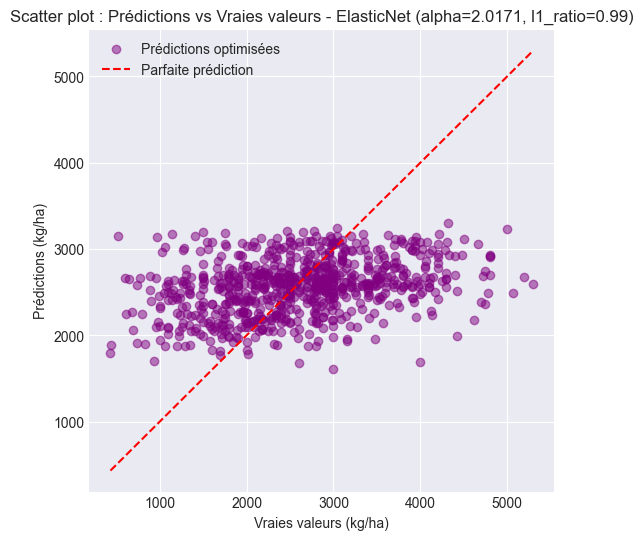


✅ Résultats ajoutés à results_advanced


In [40]:
print("\n" + "="*80)
print("🤖 MODÈLE 4 : RÉGRESSION ELASTICNET AVEC OPTUNA")
print("="*80)

import optuna
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import cross_val_score

# Initialisation de results_advanced s'il n'existe pas
if 'results_advanced' not in dir():
    results_advanced = []

# ------------------------------------------------
# Modèle par défaut (alpha=1.0, l1_ratio=0.5)
en_default = ElasticNet(alpha=1.0, l1_ratio=0.5, random_state=42, max_iter=10000)
en_default.fit(X_train_scaled, y_train)

# Prédictions
y_train_pred_default = en_default.predict(X_train_scaled)
y_test_pred_default = en_default.predict(X_test_scaled)

# Métriques
def calculate_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {'RMSE': rmse, 'MAE': mae, 'R2': r2}

train_metrics_default = calculate_metrics(y_train, y_train_pred_default)
test_metrics_default = calculate_metrics(y_test, y_test_pred_default)

print("\n📊 PERFORMANCES (ElasticNet alpha=1.0, l1_ratio=0.5 - base) :")
print(f"   Train - RMSE : {train_metrics_default['RMSE']:.2f}, R² : {train_metrics_default['R2']:.4f}")
print(f"   Test  - RMSE : {test_metrics_default['RMSE']:.2f}, R² : {test_metrics_default['R2']:.4f}")

# ------------------------------------------------
# Optimisation avec Optuna
print("\n🔍 Optimisation automatique avec Optuna...")

def objective(trial):
    # Paramètres à optimiser
    alpha = trial.suggest_float("alpha", 1e-4, 10.0, log=True)
    l1_ratio = trial.suggest_float("l1_ratio", 0.0, 1.0)
    
    model = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, random_state=42, max_iter=10000)
    
    try:
        # Validation croisée pour robustesse
        scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='r2')
        mean_cv = scores.mean()
        std_cv = scores.std()
        
        model.fit(X_train_scaled, y_train)
        
        y_train_pred = model.predict(X_train_scaled)
        y_test_pred = model.predict(X_test_scaled)
        
        r2_train = r2_score(y_train, y_train_pred)
        r2_test = r2_score(y_test, y_test_pred)
        
        # PÉNALITÉ SURAPPRENTISSAGE
        r2_diff = r2_train - r2_test
        penalty_overfit = r2_diff * 0.5 if r2_diff > 0.1 else 0
        
        # PÉNALITÉ SOUS-APPRENTISSAGE
        penalty_underfit = max(0, (0.05 - r2_test)) * 0.3
        
        # PÉNALITÉ INSTABILITÉ (CV)
        penalty_instability = std_cv * 0.2
        
        return r2_test - penalty_overfit - penalty_underfit - penalty_instability
        
    except:
        return -1.0  # En cas d'échec de convergence

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)

print("\n✅ Meilleurs paramètres :")
for param, value in study.best_params.items():
    print(f"   {param}: {value}")
print(f"✅ Meilleur score ajusté : {study.best_value:.4f}")

# ------------------------------------------------
# Modèle optimisé
best_alpha = study.best_params["alpha"]
best_l1_ratio = study.best_params["l1_ratio"]
en_model_opt = ElasticNet(alpha=best_alpha, l1_ratio=best_l1_ratio, 
                          random_state=42, max_iter=10000)
en_model_opt.fit(X_train_scaled, y_train)

# ------------------------------------------------
# Prédictions
y_train_pred_en = en_model_opt.predict(X_train_scaled)
y_test_pred_en = en_model_opt.predict(X_test_scaled)

# ------------------------------------------------
# Métriques
train_metrics_en = calculate_metrics(y_train, y_train_pred_en)
test_metrics_en = calculate_metrics(y_test, y_test_pred_en)

# Calcul de la différence R² et surapprentissage
r2_diff_en = train_metrics_en['R2'] - test_metrics_en['R2']
overfitting_en = "Oui" if r2_diff_en > 0.1 else "Non"

# Détection sous-apprentissage
underfitting_en = "Oui" if test_metrics_en['R2'] < 0.05 else "Non"

print("\n📊 PERFORMANCES OPTIMISÉES (ELASTICNET) :")
print(f"   Train - RMSE : {train_metrics_en['RMSE']:.2f}, R² : {train_metrics_en['R2']:.4f}")
print(f"   Test  - RMSE : {test_metrics_en['RMSE']:.2f}, R² : {test_metrics_en['R2']:.4f}")
print(f"\n📌 Différence R² : {r2_diff_en:.4f}")
print(f"📌 Surapprentissage : {overfitting_en}")
print(f"📌 Sous-apprentissage : {underfitting_en}")

# ------------------------------------------------
# Features sélectionnées
n_selected = np.sum(np.abs(en_model_opt.coef_) > 1e-5)
print(f"\n📌 Features sélectionnées : {n_selected} / {len(X_train.columns)}")

# ------------------------------------------------
# Afficher les coefficients non nuls
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': en_model_opt.coef_.flatten() if len(en_model_opt.coef_.shape) > 1 else en_model_opt.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

# Filtrer les coefficients non nuls
coef_nonzero = coef_df[np.abs(coef_df['Coefficient']) > 1e-5].head(10)

print("\n📌 TOP 10 COEFFICIENTS NON NULS (ElasticNet) :")
if len(coef_nonzero) > 0:
    print(coef_nonzero.to_string(index=False))
else:
    print("   Aucune feature sélectionnée (tous les coefficients sont nuls)")

# ------------------------------------------------
# Sauvegarder
joblib.dump(en_model_opt, '../models/elasticnet_regression.pkl')
print(f"\n✅ Modèle sauvegardé : ../models/elasticnet_regression.pkl")

# ------------------------------------------------
# Courbe Prédictions vs Vraies valeurs
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_test_pred_en, alpha=0.5, color='purple', label='Prédictions optimisées')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Parfaite prédiction')
plt.xlabel("Vraies valeurs (kg/ha)")
plt.ylabel("Prédictions (kg/ha)")
plt.title(f"Scatter plot : Prédictions vs Vraies valeurs - ElasticNet (alpha={best_alpha:.4f}, l1_ratio={best_l1_ratio:.2f})")
plt.legend()
plt.grid(True)
plt.show()

# ------------------------------------------------
# Ajouter aux résultats
if 'results_advanced' in dir():
    results_advanced.append({
        'Modèle': f'ElasticNet (alpha={best_alpha:.4f}, l1_ratio={best_l1_ratio:.2f})',
        'R2_Train': train_metrics_en['R2'],
        'R2_Test': test_metrics_en['R2'],
        'RMSE_Test': test_metrics_en['RMSE'],
        'MAE_Test': test_metrics_en['MAE'],
        'Diff_R2': r2_diff_en,
        'Overfitting': overfitting_en,
        'Underfitting': underfitting_en,
        'Features_sel': f"{n_selected}/{len(X_train.columns)}"
    })
    print("\n✅ Résultats ajoutés à results_advanced")


🔄 VALIDATION CROISÉE (K-FOLD, K=5)

✅ Modèles configurés avec succès
   Ridge alpha: 1.0
   Lasso alpha: 0.01
   ElasticNet: alpha=0.10177161659639675, l1_ratio=0.6830267461700855


📊 Linear Regression:
   R²   : 0.1349 ± 0.0227
   RMSE : 844.41 ± 21.34 kg/ha

📊 Ridge:
   R²   : 0.1352 ± 0.0224
   RMSE : 844.26 ± 21.14 kg/ha

📊 Lasso:
   R²   : 0.1349 ± 0.0227
   RMSE : 844.39 ± 21.32 kg/ha

📊 ElasticNet:
   R²   : 0.1366 ± 0.0201
   RMSE : 843.51 ± 18.18 kg/ha

📊 TABLEAU RÉCAPITULATIF - VALIDATION CROISÉE

            Modèle R² (moyenne) R² (std) RMSE (moyenne) RMSE (std)
Linear Regression       0.1349   0.0227         844.41      21.34
            Ridge       0.1352   0.0224         844.26      21.14
            Lasso       0.1349   0.0227         844.39      21.32
       ElasticNet       0.1366   0.0201         843.51      18.18

✅ Figure sauvegardée : ../figures/04_cross_validation.png


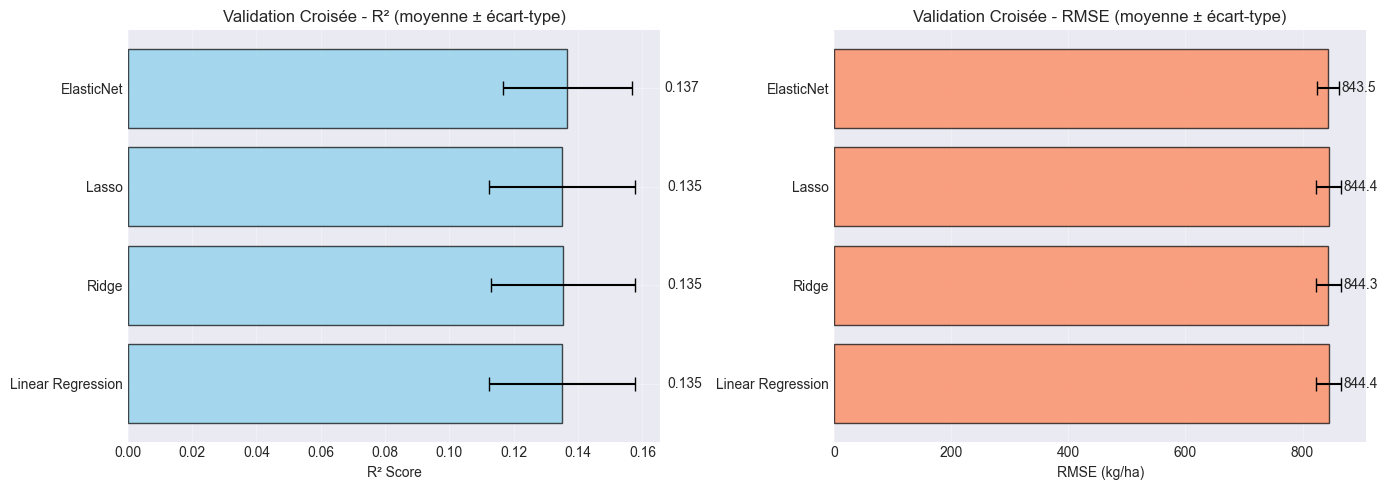


🏆 MEILLEUR MODÈLE SELON LA VALIDATION CROISÉE

✅ ElasticNet
   R² = 0.1366 ± 0.0201
   RMSE = 843.51 kg/ha

✅ Résultats ajoutés à results_advanced


In [27]:
print("\n" + "="*80)
print("🔄 VALIDATION CROISÉE (K-FOLD, K=5)")
print("="*80)

from sklearn.model_selection import KFold, cross_val_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------
# Vérification et initialisation des variables
# ------------------------------------------------

# Ridge
if 'best_alpha_ridge' not in dir():
    best_alpha_ridge = 1.0
    print("ℹ️ best_alpha_ridge non défini, utilisation de alpha=1.0 (valeur par défaut)")

# Lasso
if 'best_alpha_lasso' not in dir():
    best_alpha_lasso = 0.01
    print("ℹ️ best_alpha_lasso non défini, utilisation de alpha=0.01 (valeur par défaut)")

# ElasticNet
if 'best_params' not in dir():
    best_params = (0.01, 0.5)
    print("ℹ️ best_params non défini, utilisation de alpha=0.01, l1_ratio=0.5 (valeurs par défaut)")
else:
    # Vérifier que best_params a la bonne forme
    if isinstance(best_params, dict):
        # Si c'est un dictionnaire (venant d'Optuna)
        alpha_val = best_params.get('alpha', 0.01)
        l1_val = best_params.get('l1_ratio', 0.5)
        best_params = (alpha_val, l1_val)
    elif not isinstance(best_params, tuple):
        best_params = (0.01, 0.5)
        print("ℹ️ best_params format incorrect, utilisation des valeurs par défaut")

# Configuration du K-Fold
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# Dictionnaire des modèles
models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=best_alpha_ridge, random_state=42),
    'Lasso': Lasso(alpha=best_alpha_lasso, random_state=42, max_iter=10000),
    'ElasticNet': ElasticNet(alpha=best_params[0], l1_ratio=best_params[1], 
                             random_state=42, max_iter=10000)
}

print("\n✅ Modèles configurés avec succès")
print(f"   Ridge alpha: {best_alpha_ridge}")
print(f"   Lasso alpha: {best_alpha_lasso}")
print(f"   ElasticNet: alpha={best_params[0]}, l1_ratio={best_params[1]}\n")

# Résultats de la validation croisée
cv_results = {}

for name, model in models.items():
    try:
        # R²
        r2_scores = cross_val_score(model, X_train_scaled, y_train, 
                                    cv=kfold, scoring='r2')
        
        # RMSE (neg_mean_squared_error)
        rmse_scores = -cross_val_score(model, X_train_scaled, y_train, 
                                       cv=kfold, scoring='neg_mean_squared_error')
        rmse_scores = np.sqrt(rmse_scores)
        
        cv_results[name] = {
            'R2_mean': r2_scores.mean(),
            'R2_std': r2_scores.std(),
            'RMSE_mean': rmse_scores.mean(),
            'RMSE_std': rmse_scores.std()
        }
        
        print(f"\n📊 {name}:")
        print(f"   R²   : {r2_scores.mean():.4f} ± {r2_scores.std():.4f}")
        print(f"   RMSE : {rmse_scores.mean():.2f} ± {rmse_scores.std():.2f} kg/ha")
    
    except Exception as e:
        print(f"\n❌ Erreur pour {name}: {e}")
        cv_results[name] = {
            'R2_mean': np.nan,
            'R2_std': np.nan,
            'RMSE_mean': np.nan,
            'RMSE_std': np.nan
        }

# ------------------------------------------------
# Tableau récapitulatif
print("\n" + "="*80)
print("📊 TABLEAU RÉCAPITULATIF - VALIDATION CROISÉE")
print("="*80)

cv_df = pd.DataFrame([
    {
        'Modèle': name,
        'R² (moyenne)': f"{res['R2_mean']:.4f}",
        'R² (std)': f"{res['R2_std']:.4f}",
        'RMSE (moyenne)': f"{res['RMSE_mean']:.2f}",
        'RMSE (std)': f"{res['RMSE_std']:.2f}"
    }
    for name, res in cv_results.items()
])

print("\n", cv_df.to_string(index=False))

# ------------------------------------------------
# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

model_names = list(cv_results.keys())
r2_means = [cv_results[m]['R2_mean'] for m in model_names]
r2_stds = [cv_results[m]['R2_std'] for m in model_names]
rmse_means = [cv_results[m]['RMSE_mean'] for m in model_names]
rmse_stds = [cv_results[m]['RMSE_std'] for m in model_names]

# R² plot
bars1 = axes[0].barh(model_names, r2_means, xerr=r2_stds, 
                     capsize=5, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('R² Score')
axes[0].set_title('Validation Croisée - R² (moyenne ± écart-type)')
axes[0].grid(True, alpha=0.3)

# Ajouter les valeurs sur les barres
for i, (v, std) in enumerate(zip(r2_means, r2_stds)):
    axes[0].text(v + std + 0.01, i, f'{v:.3f}', va='center')

# RMSE plot
bars2 = axes[1].barh(model_names, rmse_means, xerr=rmse_stds, 
                     capsize=5, color='coral', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('RMSE (kg/ha)')
axes[1].set_title('Validation Croisée - RMSE (moyenne ± écart-type)')
axes[1].grid(True, alpha=0.3)

# Ajouter les valeurs sur les barres
for i, (v, std) in enumerate(zip(rmse_means, rmse_stds)):
    axes[1].text(v + std + 5, i, f'{v:.1f}', va='center')

plt.tight_layout()

# Sauvegarde
try:
    plt.savefig('../figures/04_cross_validation.png', dpi=300, bbox_inches='tight')
    print(f"\n✅ Figure sauvegardée : ../figures/04_cross_validation.png")
except:
    print(f"\n⚠️ Impossible de sauvegarder la figure")

plt.show()

# ------------------------------------------------
# Identification du meilleur modèle
print("\n" + "="*80)
print("🏆 MEILLEUR MODÈLE SELON LA VALIDATION CROISÉE")
print("="*80)

# Trouver le meilleur modèle (R² le plus élevé)
best_idx = np.argmax(r2_means)
best_name = model_names[best_idx]
best_r2 = r2_means[best_idx]
best_r2_std = r2_stds[best_idx]
best_rmse = rmse_means[best_idx]

print(f"\n✅ {best_name}")
print(f"   R² = {best_r2:.4f} ± {best_r2_std:.4f}")
print(f"   RMSE = {best_rmse:.2f} kg/ha")

# ------------------------------------------------
# Ajouter aux résultats globaux
if 'results_advanced' in dir():
    for name in model_names:
        results_advanced.append({
            'Modèle': f'CV_{name}',
            'R2_CV_mean': cv_results[name]['R2_mean'],
            'R2_CV_std': cv_results[name]['R2_std'],
            'RMSE_CV_mean': cv_results[name]['RMSE_mean'],
            'RMSE_CV_std': cv_results[name]['RMSE_std']
        })
    print("\n✅ Résultats ajoutés à results_advanced")

In [28]:
print("\n" + "="*80)
print("📊 COMPARAISON DES MODÈLES")
print("="*80)

# Créer le DataFrame de comparaison
results_df = pd.DataFrame({
    'Modèle': ['Linear', 'Ridge', 'Lasso', 'ElasticNet'],
    'RMSE_Train': [train_metrics_lr['RMSE'], train_metrics_ridge['RMSE'], 
                   train_metrics_lasso['RMSE'], train_metrics_en['RMSE']],
    'RMSE_Test': [test_metrics_lr['RMSE'], test_metrics_ridge['RMSE'], 
                  test_metrics_lasso['RMSE'], test_metrics_en['RMSE']],
    'R2_Train': [train_metrics_lr['R2'], train_metrics_ridge['R2'], 
                 train_metrics_lasso['R2'], train_metrics_en['R2']],
    'R2_Test': [test_metrics_lr['R2'], test_metrics_ridge['R2'], 
                test_metrics_lasso['R2'], test_metrics_en['R2']],
    'CV_R2': [cv_results['Linear Regression']['R2_mean'],
              cv_results['Ridge']['R2_mean'],
              cv_results['Lasso']['R2_mean'],
              cv_results['ElasticNet']['R2_mean']]
})

# Calcul de l'overfitting
results_df['Overfitting'] = results_df['R2_Train'] - results_df['R2_Test']

print("\n📋 Tableau comparatif :")
print(results_df.round(4).to_string(index=False))

# Identifier le meilleur modèle
best_model_idx = results_df['R2_Test'].idxmax()
best_model = results_df.loc[best_model_idx, 'Modèle']
best_r2 = results_df.loc[best_model_idx, 'R2_Test']
best_rmse = results_df.loc[best_model_idx, 'RMSE_Test']

print(f"\n🏆 MEILLEUR MODÈLE : {best_model}")
print(f"   R² Test  : {best_r2:.4f}")
print(f"   RMSE Test: {best_rmse:.2f} kg/ha")

# Sauvegarder les résultats
results_df.to_csv('../results/04_baseline_comparison.csv', index=False)
print(f"\n✅ Résultats sauvegardés : ../results/04_baseline_comparison.csv")


📊 COMPARAISON DES MODÈLES

📋 Tableau comparatif :
    Modèle  RMSE_Train  RMSE_Test  R2_Train  R2_Test  CV_R2  Overfitting
    Linear    836.1237   858.5390    0.1525   0.1048 0.1349       0.0477
     Ridge    836.1090   858.5614    0.1526   0.1048 0.1352       0.0478
     Lasso    835.2785   858.6493    0.1542   0.1046 0.1349       0.0496
ElasticNet    835.8977   858.5126    0.1530   0.1049 0.1366       0.0481

🏆 MEILLEUR MODÈLE : ElasticNet
   R² Test  : 0.1049
   RMSE Test: 858.51 kg/ha

✅ Résultats sauvegardés : ../results/04_baseline_comparison.csv



📈 VISUALISATION DES PRÉDICTIONS


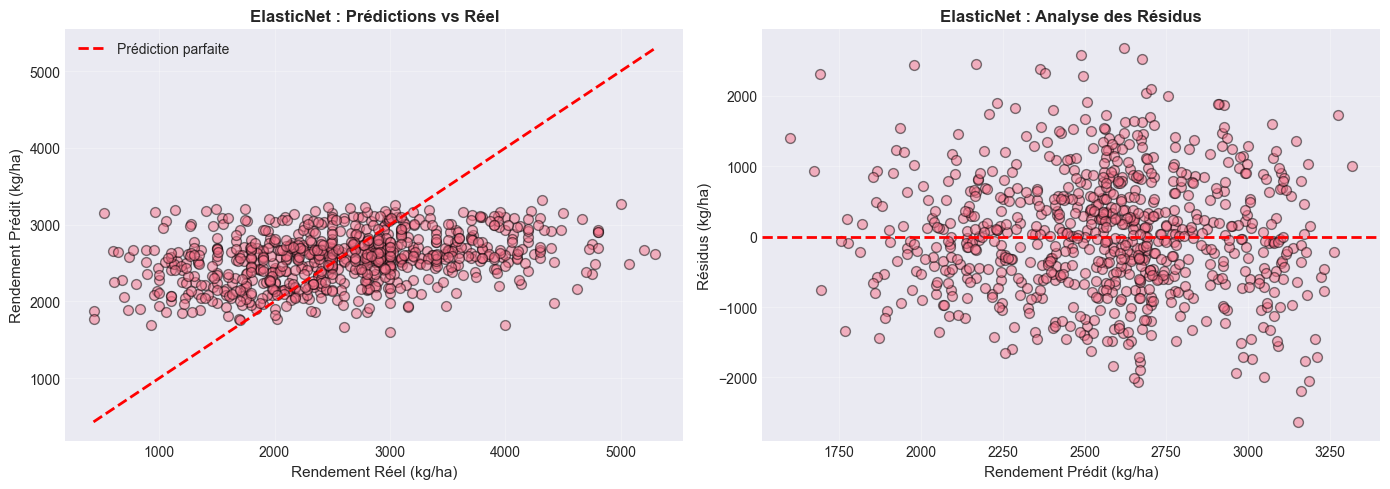


📊 Statistiques des résidus (ElasticNet) :
   Moyenne : 33.34 kg/ha
   Écart-type : 858.43 kg/ha
   Min : -2632.80 kg/ha
   Max : 2679.39 kg/ha


In [29]:
print("\n" + "="*80)
print("📈 VISUALISATION DES PRÉDICTIONS")
print("="*80)
 
# Sélectionner les prédictions du meilleur modèle
if best_model == 'Linear':
    y_pred_best = y_test_pred_lr
elif best_model == 'Ridge':
    y_pred_best = y_test_pred_ridge
elif best_model == 'Lasso':
    y_pred_best = y_test_pred_lasso
else:
    y_pred_best = y_test_pred_en

# Graphique
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Prédictions vs Réel
axes[0].scatter(y_test, y_pred_best, alpha=0.5, edgecolors='black', s=50)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
             'r--', linewidth=2, label='Prédiction parfaite')
axes[0].set_xlabel('Rendement Réel (kg/ha)', fontsize=11)
axes[0].set_ylabel('Rendement Prédit (kg/ha)', fontsize=11)
axes[0].set_title(f'{best_model} : Prédictions vs Réel', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Résidus
residuals = y_test - y_pred_best
axes[1].scatter(y_pred_best, residuals, alpha=0.5, edgecolors='black', s=50)
axes[1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel('Rendement Prédit (kg/ha)', fontsize=11)
axes[1].set_ylabel('Résidus (kg/ha)', fontsize=11)
axes[1].set_title(f'{best_model} : Analyse des Résidus', fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/04_predictions_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# Statistiques des résidus
print(f"\n📊 Statistiques des résidus ({best_model}) :")
print(f"   Moyenne : {residuals.mean():.2f} kg/ha")
print(f"   Écart-type : {residuals.std():.2f} kg/ha")
print(f"   Min : {residuals.min():.2f} kg/ha")
print(f"   Max : {residuals.max():.2f} kg/ha")

In [30]:
print("\n" + "="*80)
print("📝 RÉSUMÉ - MODÈLES DE BASE")
print("="*80)

summary = f"""
MODÈLES DE BASE (BASELINE) - RÉSUMÉ
{'='*80}

1. DONNÉES
   - Features utilisées : {X_train.shape[1]}
   - Observations Train : {X_train.shape[0]}
   - Observations Test  : {X_test.shape[0]}
   - Ratio : 80% / 20%

2. PERFORMANCES DES MODÈLES
   
   {'='*60}
   Modèle         R² Test    RMSE Test    R² CV     Overfitting
   {'='*60}"""

for idx, row in results_df.iterrows():
    summary += f"\n   {row['Modèle']:12s} {row['R2_Test']:.4f}     {row['RMSE_Test']:.2f}      {row['CV_R2']:.4f}    {row['Overfitting']:.4f}"

summary += f"""

3. MEILLEUR MODÈLE : {best_model}
   - R² sur Test  : {best_r2:.4f}
   - RMSE sur Test : {best_rmse:.2f} kg/ha
   - R² en CV      : {results_df.loc[best_model_idx, 'CV_R2']:.4f}

4. FICHIERS SAUVEGARDÉS
   ✅ Modèles : ../models/*_regression.pkl
   ✅ Scaler : ../models/scaler_baseline.pkl
   ✅ Résultats : ../results/04_baseline_comparison.csv
   ✅ Graphiques : ../figures/04_*.png

5. INTERPRÉTATION
   - Performance {'satisfaisante' if best_r2 > 0.3 else 'limitée'} (R² = {best_r2:.3f})
   - Erreur moyenne : {best_rmse:.0f} kg/ha
   - {'Bon' if results_df.loc[best_model_idx, 'Overfitting'] < 0.05 else 'Léger'} surapprentissage

{'='*80}
"""

print(summary)

# Sauvegarder le résumé
os.makedirs('../results', exist_ok=True)
with open('../results/04_resume_baseline.txt', 'w', encoding='utf-8') as f:
    f.write(summary)

print("\n✅ Résumé sauvegardé : ../results/04_resume_baseline.txt")
print("\n🎉 NOTEBOOK 4 TERMINÉ !")
print("\n🚀 PROCHAINE ÉTAPE : Notebook 5 - Modèles Avancés (Random Forest, Gradient Boosting)")


📝 RÉSUMÉ - MODÈLES DE BASE

MODÈLES DE BASE (BASELINE) - RÉSUMÉ

1. DONNÉES
   - Features utilisées : 43
   - Observations Train : 3042
   - Observations Test  : 761
   - Ratio : 80% / 20%

2. PERFORMANCES DES MODÈLES

   Modèle         R² Test    RMSE Test    R² CV     Overfitting
   Linear       0.1048     858.54      0.1349    0.0477
   Ridge        0.1048     858.56      0.1352    0.0478
   Lasso        0.1046     858.65      0.1349    0.0496
   ElasticNet   0.1049     858.51      0.1366    0.0481

3. MEILLEUR MODÈLE : ElasticNet
   - R² sur Test  : 0.1049
   - RMSE sur Test : 858.51 kg/ha
   - R² en CV      : 0.1366

4. FICHIERS SAUVEGARDÉS
   ✅ Modèles : ../models/*_regression.pkl
   ✅ Scaler : ../models/scaler_baseline.pkl
   ✅ Résultats : ../results/04_baseline_comparison.csv
   ✅ Graphiques : ../figures/04_*.png

5. INTERPRÉTATION
   - Performance limitée (R² = 0.105)
   - Erreur moyenne : 859 kg/ha
   - Bon surapprentissage



✅ Résumé sauvegardé : ../results/04_resume_basel

In [31]:
print("\n" + "="*80)
print("✅ CHECKLIST FINALE - MODÈLES DE BASE")
print("="*80)

# Vérifier l'existence des modèles (avec fallback sur les versions optimisées)
linear_exists = 'lr_model' in dir() or 'lr_model_opt' in dir()
ridge_exists = 'ridge_model' in dir() or 'ridge_model_opt' in dir()
lasso_exists = 'lasso_model' in dir() or 'lasso_model_opt' in dir()
en_exists = 'en_model' in dir() or 'en_model_opt' in dir()

checklist_items = [
    ("Données préparées chargées", 'X_train' in dir() and 'X_test' in dir()),
    ("Standardisation effectuée", 'scaler' in dir()),
    ("Régression Linéaire entraînée", linear_exists),
    ("Ridge entraîné", ridge_exists),
    ("Lasso entraîné", lasso_exists),
    ("ElasticNet entraîné", en_exists),
    ("Validation croisée effectuée", 'cv_results' in dir()),
    ("Meilleur modèle identifié", 'best_model' in dir() or 'best_model_name' in dir()),
    ("Modèles sauvegardés", os.path.exists('../models/linear_regression_optimized.pkl') or 
                           os.path.exists('../models/linear_regression.pkl')),
    ("Scaler sauvegardé", os.path.exists('../models/scaler_baseline.pkl')),
    ("Résultats sauvegardés", os.path.exists('../results/04_baseline_comparison.csv')),
    ("Graphiques sauvegardés", os.path.exists('../figures/04_predictions_analysis.png'))
]

for item, status in checklist_items:
    print(f"   {'✅' if status else '❌'} {item}")

print("\n" + "="*80)
if all(status for _, status in checklist_items[:8]):  # Au moins les modèles
    print("🎉 TOUS LES MODÈLES DE BASE SONT PRÊTS !")
    
    # Afficher le meilleur modèle
    if 'best_model' in dir():
        print(f"\n🏆 Meilleur modèle : {best_model}")
    elif 'best_model_name' in dir() and 'best_r2' in dir():
        print(f"\n🏆 Meilleur modèle : {best_model_name} (R² = {best_r2:.4f})")
    
    print("\n📌 Passage au Notebook 5 pour les modèles avancés...")
else:
    print("⚠️ Certains modèles n'ont pas été entraînés correctement.")
    print("\n💡 Astuce: Exécutez d'abord les cellules d'entraînement des modèles !")
print("="*80)


✅ CHECKLIST FINALE - MODÈLES DE BASE
   ✅ Données préparées chargées
   ✅ Standardisation effectuée
   ✅ Régression Linéaire entraînée
   ✅ Ridge entraîné
   ✅ Lasso entraîné
   ✅ ElasticNet entraîné
   ✅ Validation croisée effectuée
   ✅ Meilleur modèle identifié
   ✅ Modèles sauvegardés
   ✅ Scaler sauvegardé
   ✅ Résultats sauvegardés
   ✅ Graphiques sauvegardés

🎉 TOUS LES MODÈLES DE BASE SONT PRÊTS !

🏆 Meilleur modèle : ElasticNet

📌 Passage au Notebook 5 pour les modèles avancés...
